# Week 4 (Module M5) — Monitoring

Every prediction the API makes gets logged automatically (see
`src/serving/logger.py`, wired into `src/serving/app.py`). This notebook
reads that log and turns it into signals worth watching -- confidence
trends, prediction volume, and the class balance the model is seeing live.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt

LOG_PATH = Path("../monitoring/prediction_log.csv")
REPORTS_DIR = Path("../reports")
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
RUN_BOOTSTRAP = True  # set to False to skip this and use only real API usage

if RUN_BOOTSTRAP:
    from PIL import Image
    from src.serving.predictor_adapter import DefectPredictorAdapter
    from src.serving.logger import log_prediction

    manifest = pd.read_csv("../data/processed/manifest.csv")
    sample = manifest.sample(n=min(100, len(manifest)), random_state=7)

    predictor = DefectPredictorAdapter()

    for _, row in sample.iterrows():
        image = Image.open(row["processed_filepath"])
        result = predictor.predict(image)
        log_prediction(Path(row["processed_filepath"]).name, result)

    print(f"Logged {len(sample)} predictions to {LOG_PATH}")
else:
    print("Skipped -- using existing log only.")


Logged 100 predictions to ../monitoring/prediction_log.csv


## Load the log

In [3]:
if not LOG_PATH.exists():
    raise FileNotFoundError(
        f"No log found at {LOG_PATH}. Either run the cell above, or make a "
        "few real requests to the API first (see /docs)."
    )

log = pd.read_csv(LOG_PATH, parse_dates=["timestamp"])
log = log.sort_values("timestamp").reset_index(drop=True)

print(f"Total logged predictions: {len(log)}")
print(f"Date range: {log['timestamp'].min()} to {log['timestamp'].max()}")
log.head()


Total logged predictions: 100
Date range: 2026-08-18 16:37:33.429215+00:00 to 2026-08-18 16:37:34.490422+00:00


,timestamp,filename,label,is_defective,confidence,raw_probability,model_used
0,2026-08-18 16:37:33.429215+00:00,cast_def_0_8679.jpeg,def_front,True,0.9593,0.9593,resnet18_transfer
1,2026-08-18 16:37:33.440751+00:00,cast_ok_0_7115.jpeg,ok_front,False,0.9974,0.0026,resnet18_transfer
2,2026-08-18 16:37:33.452886+00:00,cast_ok_0_6483.jpeg,ok_front,False,0.9897,0.0103,resnet18_transfer
3,2026-08-18 16:37:33.464547+00:00,cast_def_0_7915.jpeg,def_front,True,0.6074,0.6074,resnet18_transfer
4,2026-08-18 16:37:33.475493+00:00,cast_def_0_7136.jpeg,def_front,True,0.9707,0.9707,resnet18_transfer


## Signal 1: prediction volume over time

A sudden spike or drop in traffic is itself worth noticing -- could mean a
new batch of parts arrived, or that something upstream broke.

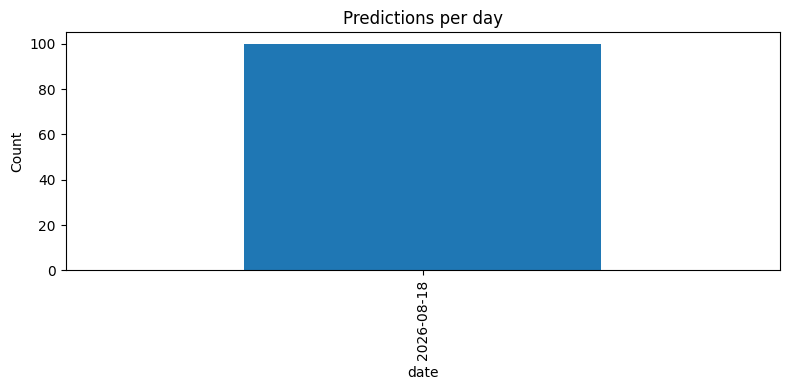

In [4]:
log["date"] = log["timestamp"].dt.date
volume = log.groupby("date").size()

fig, ax = plt.subplots(figsize=(8, 4))
volume.plot(kind="bar", ax=ax)
ax.set_title("Predictions per day")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monitoring_volume.png", dpi=150)
plt.show()


## Signal 2: confidence distribution


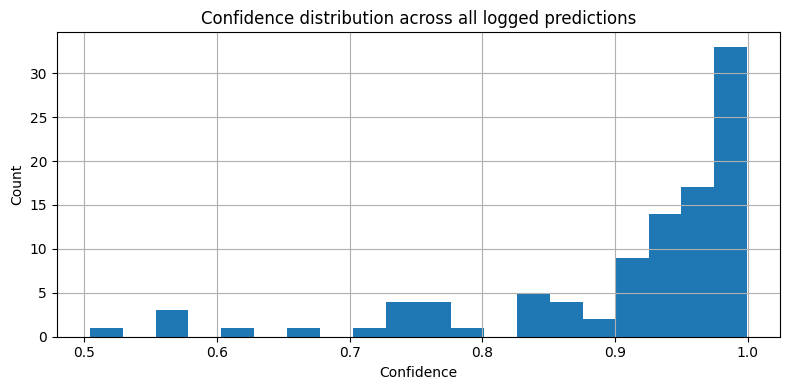

Share of predictions below 65% confidence: 5.0%


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
log["confidence"].hist(bins=20, ax=ax)
ax.set_title("Confidence distribution across all logged predictions")
ax.set_xlabel("Confidence")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monitoring_confidence_distribution.png", dpi=150)
plt.show()

low_confidence_threshold = 0.65
low_conf_rate = (log["confidence"] < low_confidence_threshold).mean()
print(f"Share of predictions below {low_confidence_threshold:.0%} confidence: {low_conf_rate:.1%}")


## Signal 3: predicted class balance over time

Training data had a roughly even mix of defective/ok images. If live
predictions drift far from that mix, it's a sign the incoming images
themselves may look different from what the model was trained on.

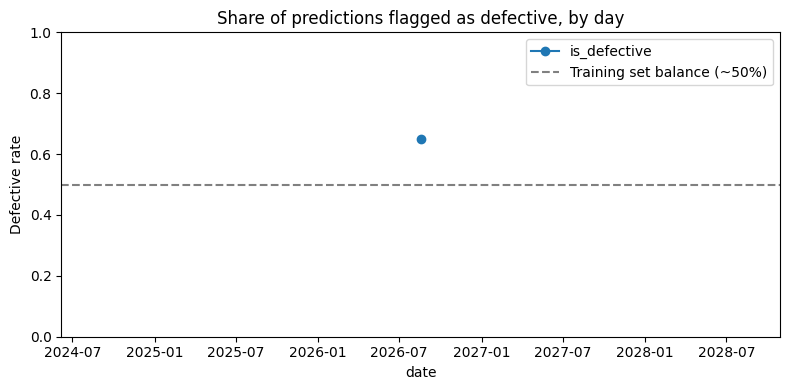

In [6]:
class_balance = log.groupby("date")["is_defective"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
class_balance.plot(kind="line", marker="o", ax=ax)
ax.axhline(0.5, color="gray", linestyle="--", label="Training set balance (~50%)")
ax.set_title("Share of predictions flagged as defective, by day")
ax.set_ylabel("Defective rate")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monitoring_class_balance.png", dpi=150)
plt.show()


## Save a summary report


In [7]:
summary = f"""# Monitoring Summary

Generated from {len(log)} logged predictions
({log['timestamp'].min()} to {log['timestamp'].max()}).

## Volume
- Total predictions: {len(log)}
- Days covered: {log['date'].nunique()}
- Average per day: {len(log) / max(log['date'].nunique(), 1):.1f}

## Confidence
- Mean confidence: {log['confidence'].mean():.3f}
- Share below {low_confidence_threshold:.0%} confidence: {low_conf_rate:.1%}

## Class balance
- Overall defective rate: {log['is_defective'].mean():.1%}
- Training set baseline: ~50%

## Suggested signals to watch (for the retraining trigger design)
- Defective rate drifting more than ~15 points from the ~50% baseline
- Mean confidence dropping notably below {log['confidence'].mean():.2f} (this run's baseline)
- Share of low-confidence (<{low_confidence_threshold:.0%}) predictions rising past {low_conf_rate:.1%}
"""

report_path = REPORTS_DIR / "monitoring_summary.md"
report_path.write_text(summary)
print(summary)
print(f"\nSaved to {report_path}")


# Monitoring Summary

Generated from 100 logged predictions
(2026-08-18 16:37:33.429215+00:00 to 2026-08-18 16:37:34.490422+00:00).

## Volume
- Total predictions: 100
- Days covered: 1
- Average per day: 100.0

## Confidence
- Mean confidence: 0.908
- Share below 65% confidence: 5.0%

## Class balance
- Overall defective rate: 65.0%
- Training set baseline: ~50%

## Suggested signals to watch (for the retraining trigger design)
- Defective rate drifting more than ~15 points from the ~50% baseline
- Mean confidence dropping notably below 0.91 (this run's baseline)
- Share of low-confidence (<65%) predictions rising past 5.0%


Saved to ../reports/monitoring_summary.md
